# Process Dataset — SageMaker-ready

Encoding, scaling and hierarchical clustering on `full_dataset.csv`.

This notebook is designed to run unchanged in:
- A local Jupyter environment.
- Amazon SageMaker Studio (Data Science / Python 3 image).
- A classic SageMaker Notebook Instance (`conda_python3` kernel).

Configuration knobs at the top of the notebook let you switch between a local path and an S3 prefix without touching the pipeline.

## 0. Environment bootstrap

Installs/upgrades the libraries the pipeline needs. `%pip` (not `!pip`) is used so the install happens inside the active kernel — the recommended pattern on SageMaker. Running twice is safe; pip will no-op if everything is already satisfied.

In [53]:
%pip install -q --upgrade \
    "pandas>=2.0" \
    "numpy>=1.24" \
    "scikit-learn>=1.3" \
    "scipy>=1.10" \
    "matplotlib>=3.7" \
    "joblib>=1.3" \
    "psutil" \
    "s3fs" \
    "pyarrow"


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [54]:
import logging
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist

# Logging — shows up cleanly in the Studio cell output and CloudWatch
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
    stream=sys.stdout,
    force=True,
)
log = logging.getLogger("process_dataset")

pd.set_option("display.max_columns", 100)
matplotlib.rcParams["figure.dpi"] = 110

log.info("python %s", sys.version.split()[0])
log.info("pandas %s | numpy %s", pd.__version__, np.__version__)
import sklearn, scipy
log.info("sklearn %s | scipy %s", sklearn.__version__, scipy.__version__)

04:30:29 | INFO | python 3.12.6
04:30:29 | INFO | pandas 3.0.2 | numpy 2.4.4
04:30:29 | INFO | sklearn 1.8.0 | scipy 1.17.1


## 1. Paths & configuration

Resolves input/output locations. Priority order:
1. Env var `DATA_DIR` (handy for SageMaker Processing / Training jobs where data lands at `/opt/ml/processing/input`).
2. S3 prefix via `S3_DATA_URI` (e.g. `s3://my-bucket/datathon/ds/`).
3. Default: the directory this notebook lives in.

In [55]:
RANDOM_STATE = 42

# Resolve the notebook's own directory in a way that works in Studio too.
try:
    NB_DIR = Path(__file__).resolve().parent  # if exported to .py
except NameError:
    NB_DIR = Path(os.getcwd()).resolve()

S3_DATA_URI = os.environ.get("S3_DATA_URI", "").rstrip("/")
DATA_DIR = os.environ.get("DATA_DIR", str(NB_DIR))

if S3_DATA_URI:
    INPUT_BASE = S3_DATA_URI
    OUTPUT_BASE = os.environ.get("S3_OUTPUT_URI", S3_DATA_URI).rstrip("/")
    log.info("Using S3 data path: %s", INPUT_BASE)
else:
    INPUT_BASE = str(Path(DATA_DIR))
    OUTPUT_BASE = str(Path(DATA_DIR))
    log.info("Using local data path: %s", INPUT_BASE)

INPUT_CSV = f"{INPUT_BASE}/full_dataset_encoded.csv"
ENCODED_OUT = f"{OUTPUT_BASE}/full_dataset_encoded.csv"
LABELLED_OUT = f"{OUTPUT_BASE}/full_dataset_hc_labels.csv"
PROFILE_OUT = f"{OUTPUT_BASE}/full_dataset_hc_profile.csv"
log.info("Input : %s", INPUT_CSV)
log.info("Output: %s", OUTPUT_BASE)

04:30:29 | INFO | Using local data path: /Users/olivercasas/Desktop/DSC-Datathon-2026
04:30:29 | INFO | Input : /Users/olivercasas/Desktop/DSC-Datathon-2026/full_dataset_encoded.csv
04:30:29 | INFO | Output: /Users/olivercasas/Desktop/DSC-Datathon-2026


## 2. Load the dataset

`pd.read_csv` works transparently with `s3://` URIs when `s3fs` is installed and the execution role has `s3:GetObject` on the bucket.

In [56]:
id_cols = ["user_id"]
numeric_cols = [
    "edad",
    "ingreso_mensual_mxn",
    "antiguedad_dias",
    "score_buro",
    "dias_desde_ultimo_login",
    "satisfaccion_1_10",
    "num_productos_activos",
    "num_no_procesadas",
    "num_transacciones",
]

In [57]:
t0 = time.time()
df = pd.read_csv(INPUT_CSV)
log.info("Loaded %s rows x %s cols in %.1fs", *df.shape, time.time() - t0)
df.head()

04:30:29 | INFO | Loaded 15025 rows x 45 cols in 0.1s


,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,nomina_domiciliada,canal_apertura,score_buro,dias_desde_ultimo_login,preferencia_canal,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico,num_no_procesadas,saldo,num_transacciones,categoria,categoria_salud,cluster_dominante,cluster_label_dominante,num_clusters_distintos,seg_0,seg_1,seg_2,seg_3,seg_4,seg_5,seg_6,seg_7,seg_8,seg_9,seg_10,seg_11,seg_12,seg_13,seg_14
0,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,False,App,527,1,app_android,10.0,False,True,es_MX,False,2,False,3.0,-73497.31,56,Débito + Crédito,Endeudamiento Medio,5,Créditos personales y diferimientos,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,False,App,714,3,app_android,8.0,False,True,es_MX,True,2,False,1.0,-8557.23,74,Débito + Crédito,Bajo Endeudamiento,3,Cotización de crédito automotriz,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,USR-00003,23,H,Chihuahua,Cuauhtémoc,Licenciatura,Estudiante,14000,1174,True,False,App,454,3,app_ios,8.0,False,True,es_MX,False,2,False,4.0,-25467.35,79,Débito + Crédito,Bajo Endeudamiento,6,Problemas técnicos y operacionales en transacc...,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,USR-00004,32,SE,Nuevo León,Guadalupe,Posgrado,Empleado,61000,1168,False,False,Fan Shop,837,16,app_ios,10.0,True,False,es_MX,True,3,False,2.0,-93133.74,66,Débito + Crédito,Bajo Endeudamiento,7,Cancelación de tarjeta de crédito,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,USR-00005,26,M,Ciudad de México,CDMX - Cuauhtémoc,Preparatoria,Empresario,27000,816,True,False,Fan Shop,533,1,app_ios,7.0,False,True,es_MX,True,2,False,2.0,-52212.24,93,Débito + Crédito,Endeudamiento Medio,5,Créditos personales y diferimientos,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


## 3. Column groups

In [58]:
id_cols = ["user_id"]

numeric_cols = [
    "edad",
    "ingreso_mensual_mxn",
    "antiguedad_dias",
    "score_buro",
    "dias_desde_ultimo_login",
    "satisfaccion_1_10",
    "num_productos_activos",
    "num_no_procesadas",
    "num_transacciones",
]

bool_cols = [
    "es_hey_pro", "recibe_remesas", "tiene_seguro",
    "nomina_domiciliada", "usa_hey_shop", "patron_uso_atipico",
]

categorical_cols = [
    "sexo",
    "nivel_educativo",
    "ocupacion",
    "preferencia_canal",
    "categoria",
    "cluster_label_dominante",
    "estado",
    "canal_apertura",
    "idioma_preferido",
    "categoria_salud",
]

# Defensive: keep only columns that actually exist
numeric_cols     = [c for c in numeric_cols     if c in df.columns]
bool_cols        = [c for c in bool_cols        if c in df.columns]
categorical_cols = [c for c in categorical_cols if c in df.columns]

# ciudad has ~83 unique values — too many dummies for clustering quality
drop_cols = [c for c in ["ciudad"] if c in df.columns]
df = df.drop(columns=drop_cols)

log.info("numeric=%d, bool=%d, categorical=%d", len(numeric_cols), len(bool_cols), len(categorical_cols))


04:30:29 | INFO | numeric=9, bool=6, categorical=10


## 4. Clean, impute, encode

In [59]:
df[categorical_cols] = df[categorical_cols].fillna("Desconocido").astype(str)
df[bool_cols] = df[bool_cols].astype(int)

num_imputer = SimpleImputer(strategy="median")
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

remaining_nans = df.isna().sum().sort_values(ascending=False)
log.info("Remaining NaNs after imputation (top 5):\n%s", remaining_nans.head())

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    prefix=categorical_cols,
    drop_first=False,
    dtype=np.int8,  # small dtype keeps memory low on SageMaker t3 instances
)
log.info("Encoded shape: %s (was %s)", df_encoded.shape, df.shape)

04:30:29 | INFO | Remaining NaNs after imputation (top 5):
user_id              0
edad                 0
categoria            0
categoria_salud      0
cluster_dominante    0
dtype: int64
04:30:29 | INFO | Encoded shape: (15025, 100) (was (15025, 44))


## 5. Scale and build the feature matrix

`float32` halves memory usage vs. `float64` with no meaningful loss in Ward distance quality.

In [60]:
scaler = RobustScaler()
df_model = df_encoded.copy()
df_model[numeric_cols] = scaler.fit_transform(df_model[numeric_cols])

# Use only numeric/bool columns — excludes id and any leftover string columns
feature_cols = [
    c for c in df_model.select_dtypes(include=[np.number, bool]).columns
    if c not in id_cols
]
X = df_model[feature_cols].to_numpy(dtype=np.float32)
log.info("Feature matrix: shape=%s dtype=%s mem=%.1f MB",
         X.shape, X.dtype, X.nbytes / 1e6)


04:30:29 | INFO | Feature matrix: shape=(15025, 99) dtype=float32 mem=5.9 MB


## 6. Choose a sample size that fits in RAM

`scipy.cluster.hierarchy.linkage` needs an `O(n²)` condensed distance matrix (≈`4·n·(n-1)/2` bytes in float32). On a `ml.t3.medium` (≈4 GB) we cap the sample so the pdist matrix stays under ~500 MB. On bigger instances we use up to 5k rows.

In [61]:
try:
    import psutil
    total_mem_gb = psutil.virtual_memory().total / 1e9
except Exception:
    total_mem_gb = 4.0  # conservative fallback

# budget ~12% of RAM for the condensed distance matrix
budget_bytes = 0.12 * total_mem_gb * 1e9
# n * (n-1) / 2 * 4 bytes <= budget  =>  n <= sqrt(budget / 2)
n_by_mem = int(np.sqrt(budget_bytes / 2))
SAMPLE_SIZE = int(min(5000, n_by_mem, X.shape[0]))
log.info("Detected ~%.1f GB RAM -> dendrogram sample size = %d", total_mem_gb, SAMPLE_SIZE)

rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(X.shape[0], size=SAMPLE_SIZE, replace=False)
X_sample = X[sample_idx]

04:30:29 | INFO | Detected ~8.6 GB RAM -> dendrogram sample size = 5000


## 7. Dendrogram (sample) + cophenetic correlation

In [62]:
t0 = time.time()
Z = linkage(X_sample, method="ward")
log.info("linkage done in %.1fs", time.time() - t0)

coph_corr, _ = cophenet(Z, pdist(X_sample))
log.info("Cophenetic correlation (sample): %.4f", coph_corr)

04:30:30 | INFO | linkage done in 0.6s
04:30:30 | INFO | Cophenetic correlation (sample): 0.6646


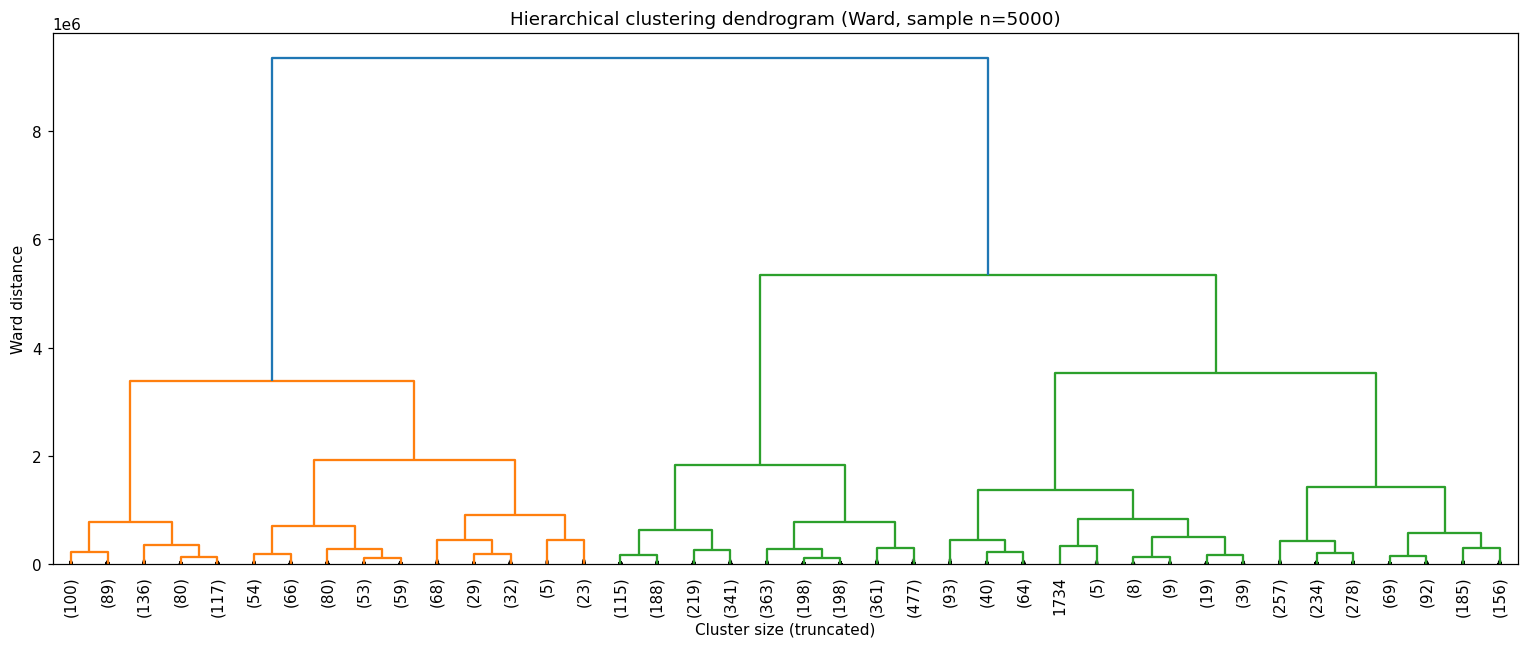

In [63]:
fig = plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=40,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
)
plt.title(f"Hierarchical clustering dendrogram (Ward, sample n={SAMPLE_SIZE})")
plt.xlabel("Cluster size (truncated)")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()
plt.close(fig)

## 8. Pick `k` with a silhouette sweep on the sample

In [64]:
candidate_ks = [2, 3, 4, 5, 6, 7, 8]
scores = {}
for k in candidate_ks:
    labels_k = fcluster(Z, t=k, criterion="maxclust")
    if len(np.unique(labels_k)) < 2:
        continue
    s = silhouette_score(X_sample, labels_k, metric="euclidean")
    scores[k] = float(s)
    log.info("k=%d  silhouette=%.4f", k, s)

best_k = max(scores, key=scores.get)
log.info("Best k by silhouette on sample: %d", best_k)

04:30:31 | INFO | k=2  silhouette=0.6121
04:30:32 | INFO | k=3  silhouette=0.5025
04:30:32 | INFO | k=4  silhouette=0.5219
04:30:32 | INFO | k=5  silhouette=0.5128
04:30:32 | INFO | k=6  silhouette=0.5191
04:30:32 | INFO | k=7  silhouette=0.5128
04:30:32 | INFO | k=8  silhouette=0.5127
04:30:32 | INFO | Best k by silhouette on sample: 2


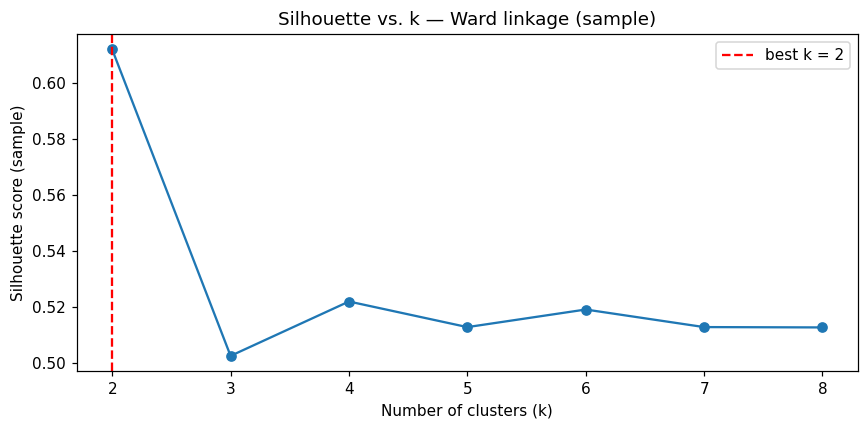

In [65]:
fig = plt.figure(figsize=(8, 4))
plt.plot(list(scores.keys()), list(scores.values()), marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"best k = {best_k}")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score (sample)")
plt.title("Silhouette vs. k — Ward linkage (sample)")
plt.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

## 9. Fit on the full dataset with a connectivity constraint

Unconstrained Ward on 15k rows builds the full distance tree in memory. Passing a sparse k-NN `connectivity` graph tells scikit-learn to only consider local merges, which cuts memory from `O(n²)` to `O(n·k)` and usually runs much faster on a SageMaker CPU instance. Silhouette is computed on a 5k subsample because the full one is `O(n²)`.

In [66]:
N_CLUSTERS = best_k  # override here if the dendrogram suggests differently

t0 = time.time()
connectivity = kneighbors_graph(
    X,
    n_neighbors=30,
    include_self=False,
    n_jobs=-1,
)
# Symmetrize — required for Ward when using a connectivity matrix
connectivity = 0.5 * (connectivity + connectivity.T)
log.info("k-NN connectivity built in %.1fs (nnz=%d)", time.time() - t0, connectivity.nnz)

t0 = time.time()
agg = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    linkage="ward",
    connectivity=connectivity,
)
labels = agg.fit_predict(X)
log.info("AgglomerativeClustering fit in %.1fs", time.time() - t0)

sizes = pd.Series(labels).value_counts().sort_index()
log.info("Cluster sizes:\n%s", sizes.to_string())

04:30:33 | INFO | k-NN connectivity built in 0.4s (nnz=484456)
04:30:34 | INFO | AgglomerativeClustering fit in 1.2s
04:30:34 | INFO | Cluster sizes:
0    13034
1     1991


In [67]:
eval_idx = rng.choice(X.shape[0], size=min(5000, X.shape[0]), replace=False)
sil_full = silhouette_score(X[eval_idx], labels[eval_idx], metric="euclidean", n_jobs=-1)
log.info("Silhouette (full model, 5k sample): %.4f", sil_full)

04:30:34 | INFO | Silhouette (full model, 5k sample): 0.6438


## 10. Attach labels & profile clusters

In [68]:
df_labelled = df.copy()
df_labelled["hc_cluster"] = labels

profile = (
    df_labelled.groupby("hc_cluster")[numeric_cols + bool_cols]
    .mean(numeric_only=True)
    .round(2)
)
profile["count"] = df_labelled.groupby("hc_cluster").size()
profile

,edad,ingreso_mensual_mxn,antiguedad_dias,score_buro,dias_desde_ultimo_login,satisfaccion_1_10,num_productos_activos,num_no_procesadas,num_transacciones,es_hey_pro,recibe_remesas,tiene_seguro,nomina_domiciliada,usa_hey_shop,patron_uso_atipico,count
hc_cluster,,,,,,,,,,,,,,,,
0,36.72,27928.15,932.20,602.51,20.60,7.35,2.11,1.81,52.15,0.45,0.08,0.24,0.35,0.27,0.05,13034
1,40.25,42006.28,954.14,722.79,6.79,8.48,3.01,1.52,61.62,0.74,0.09,0.49,0.28,0.34,0.04,1991


In [69]:
dominant = {}
for col in categorical_cols:
    dominant[col] = (
        df_labelled.groupby("hc_cluster")[col]
        .agg(lambda s: s.value_counts().index[0])
    )
dominant_df = pd.DataFrame(dominant)
dominant_df

,sexo,nivel_educativo,ocupacion,preferencia_canal,categoria,cluster_label_dominante,estado,canal_apertura,idioma_preferido,categoria_salud
hc_cluster,,,,,,,,,,
0,M,Licenciatura,Empleado,app_ios,Débito + Crédito,Problemas técnicos y operacionales en transacc...,Ciudad de México,App,es_MX,Sin Información
1,M,Licenciatura,Empleado,app_ios,Débito + Crédito,Problemas técnicos y operacionales en transacc...,Ciudad de México,App,es_MX,Bajo Endeudamiento


## 11. Save outputs

Writes support both local paths and `s3://` URIs. On SageMaker Processing jobs point `S3_OUTPUT_URI` (or `DATA_DIR=/opt/ml/processing/output`) to the expected output channel.

In [70]:
df_encoded.to_csv(ENCODED_OUT, index=False)
df_labelled.to_csv(LABELLED_OUT, index=False)
profile.join(dominant_df).to_csv(PROFILE_OUT)

log.info("Saved: %s  %s", ENCODED_OUT, df_encoded.shape)
log.info("Saved: %s  %s", LABELLED_OUT, df_labelled.shape)
log.info("Saved: %s  (profile)", PROFILE_OUT)

04:30:35 | INFO | Saved: /Users/olivercasas/Desktop/DSC-Datathon-2026/full_dataset_encoded.csv  (15025, 100)
04:30:35 | INFO | Saved: /Users/olivercasas/Desktop/DSC-Datathon-2026/full_dataset_hc_labels.csv  (15025, 45)
04:30:35 | INFO | Saved: /Users/olivercasas/Desktop/DSC-Datathon-2026/full_dataset_hc_profile.csv  (profile)
